# Statistical Significance Tests for RQ1: English ASR

**Question:** Do sparse Mixture-of-Experts (MoE) FastConformer-CTC models produce measurably different WER from dense FastConformer baselines on English adult and child speech?

**Method:** Paired speaker-level non-parametric bootstrap (Bisani & Ney, 2004), the compulsory model-comparison test specified in the IST-ASR course handout. Speakers are resampled with replacement; utterances within each selected speaker are included in full. This accounts for within-speaker correlation and produces conservative confidence intervals.

**Tested statistic:**

$$\Delta\text{WER} = \text{WER}_A - \text{WER}_B$$

**Decision rule:** If the 95\% bootstrap confidence interval excludes zero, the difference is statistically significant. All $p$-values are corrected for multiple comparisons using Benjamini-Hochberg FDR at $q = 0.05$.

---

### Comparisons

| \# | Test | Test set | Model A | Model B | $H_1$ direction |
|---|---|---|---|---|---|
| 1a | MoE vs Dense (adult stage) | adult | EN-MoE$_\text{LS}$ | EN-Dense$_\text{LS}$ | one-sided ($<0$) |
| 1b | MoE vs Dense (child stage) | adult | EN-MoE$_\text{LB-off}$ | EN-Dense$_\text{MyST}$ | one-sided ($<0$) |
| 1c | MoE vs Dense (child stage) | adult | EN-MoE$_\text{LB-on}$ | EN-Dense$_\text{MyST}$ | one-sided ($<0$) |
| 2a | MoE vs Dense (adult stage) | child | EN-MoE$_\text{LS}$ | EN-Dense$_\text{LS}$ | one-sided ($<0$) |
| 2b | MoE vs Dense (child stage) | child | EN-MoE$_\text{LB-off}$ | EN-Dense$_\text{MyST}$ | one-sided ($<0$) |
| 2c | MoE vs Dense (child stage) | child | EN-MoE$_\text{LB-on}$ | EN-Dense$_\text{MyST}$ | one-sided ($<0$) |
| 3a | LB-on vs LB-off | adult | EN-MoE$_\text{LB-on}$ | EN-MoE$_\text{LB-off}$ | two-sided ($\neq 0$) |
| 3b | LB-on vs LB-off | child | EN-MoE$_\text{LB-on}$ | EN-MoE$_\text{LB-off}$ | two-sided ($\neq 0$) |


## Hypotheses

### Test 1 — MoE vs Dense on adult speech (comparisons 1a-1c)

Does MoE maintain or improve adult-speaker performance?

$$H_0\colon \text{WER}_{\text{MoE},\,\text{adult}} - \text{WER}_{\text{Dense},\,\text{adult}} = 0$$

$$H_1\colon \text{WER}_{\text{MoE},\,\text{adult}} - \text{WER}_{\text{Dense},\,\text{adult}} < 0$$

Reject $H_0$ if the entire 95% CI lies below zero.

### Test 2 — MoE vs Dense on child speech (comparisons 2a-2c)

Does MoE improve child-speaker performance?

$$H_0\colon \text{WER}_{\text{MoE},\,\text{child}} - \text{WER}_{\text{Dense},\,\text{child}} = 0$$

$$H_1\colon \text{WER}_{\text{MoE},\,\text{child}} - \text{WER}_{\text{Dense},\,\text{child}} < 0$$

Reject $H_0$ if the entire 95% CI lies below zero.

### Test 3 — Load balancing effect (comparisons 3a-3b)

Does load balancing change WER in either direction?

$$H_0\colon \text{WER}_{\text{LB-on}} - \text{WER}_{\text{LB-off}} = 0$$

$$H_1\colon \text{WER}_{\text{LB-on}} - \text{WER}_{\text{LB-off}} \neq 0$$

Reject $H_0$ if the 95% CI lies entirely above or entirely below zero.


## 1. Configuration

In [1]:
import os
import json
import re
import time
import gc

import numpy as np
import pandas as pd
import jiwer
import torch

# ── Paths ──────────────────────────────────────────────────────────────────────
W     = "/lp-dev/amelia/inclusive-asr-moe/final_weights"
CACHE = "/lp-dev/amelia/inclusive-asr-moe/stats/cache_en"
os.makedirs(CACHE, exist_ok=True)

# ── Compute ────────────────────────────────────────────────────────────────────
DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE     = 32
NUM_BOOTSTRAPS = 10000
SEED_BASE      = 12345

# ── Models ─────────────────────────────────────────────────────────────────────
MODELS = {
    "EN-Dense_LS":   os.path.join(W, "en_adult_fastconformer.nemo"),   # Dense, adult-only
    "EN-MoE_LS":     os.path.join(W, "en_adult_moe.nemo"),             # MoE,   adult-only
    "EN-Dense_MyST": os.path.join(W, "en_child_fastconformer.nemo"),   # Dense, child-finetuned
    "EN-MoE_LB-off": os.path.join(W, "en_child_moe_lb_off.nemo"),     # MoE,   child-finetuned, LB off
    "EN-MoE_LB-on":  os.path.join(W, "en_child_moe_lb_on.nemo"),      # MoE,   child-finetuned, LB on
}

# ── Test sets ──────────────────────────────────────────────────────────────────
TEST_SETS = {
    "adult": "/data/librispeech/test_clean.json",         # LibriSpeech test-clean
    "child": "/lp-dev/amelia/data/myst/filtered_data/test.json",  # MyST test partition
}

# ── Verify ─────────────────────────────────────────────────────────────────────
print(f"Device: {DEVICE}")
print(f"Cache:  {CACHE}")
print()
for name, path in MODELS.items():
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"  [{status:>7}]  {name}")

Device: cuda
Cache:  /lp-dev/amelia/inclusive-asr-moe/stats/cache_en

  [     OK]  EN-Dense_LS
  [     OK]  EN-MoE_LS
  [     OK]  EN-Dense_MyST
  [     OK]  EN-MoE_LB-off
  [     OK]  EN-MoE_LB-on


## 2. Comparison definitions

Each entry defines one paired bootstrap test: which two models are compared, on which
test set, with what directional hypothesis. The `expected_direction` field controls
how the CI is interpreted in the decision table at the end.

In [2]:
COMPARISONS = [
    # ── Test 1: MoE vs Dense on adult speech ───────────────────────────────────
    {
        "test_id": "1a", "test_set": "adult",
        "model_A": "EN-MoE_LS",     "model_B": "EN-Dense_LS",
        "expected_direction": "negative",
        "description": "Adult-stage MoE vs Dense on adult speech",
    },
    {
        "test_id": "1b", "test_set": "adult",
        "model_A": "EN-MoE_LB-off", "model_B": "EN-Dense_MyST",
        "expected_direction": "negative",
        "description": "Child-stage MoE (LB-off) vs Dense on adult speech",
    },
    {
        "test_id": "1c", "test_set": "adult",
        "model_A": "EN-MoE_LB-on",  "model_B": "EN-Dense_MyST",
        "expected_direction": "negative",
        "description": "Child-stage MoE (LB-on) vs Dense on adult speech",
    },

    # ── Test 2: MoE vs Dense on child speech ───────────────────────────────────
    {
        "test_id": "2a", "test_set": "child",
        "model_A": "EN-MoE_LS",     "model_B": "EN-Dense_LS",
        "expected_direction": "negative",
        "description": "Adult-stage MoE vs Dense on child speech",
    },
    {
        "test_id": "2b", "test_set": "child",
        "model_A": "EN-MoE_LB-off", "model_B": "EN-Dense_MyST",
        "expected_direction": "negative",
        "description": "Child-stage MoE (LB-off) vs Dense on child speech",
    },
    {
        "test_id": "2c", "test_set": "child",
        "model_A": "EN-MoE_LB-on",  "model_B": "EN-Dense_MyST",
        "expected_direction": "negative",
        "description": "Child-stage MoE (LB-on) vs Dense on child speech",
    },

    # ── Test 3: Load balancing effect ──────────────────────────────────────────
    {
        "test_id": "3a", "test_set": "adult",
        "model_A": "EN-MoE_LB-on",  "model_B": "EN-MoE_LB-off",
        "expected_direction": "either",
        "description": "LB-on vs LB-off on adult speech",
    },
    {
        "test_id": "3b", "test_set": "child",
        "model_A": "EN-MoE_LB-on",  "model_B": "EN-MoE_LB-off",
        "expected_direction": "either",
        "description": "LB-on vs LB-off on child speech",
    },
]

pd.DataFrame(COMPARISONS)[["test_id", "description", "test_set", "model_A", "model_B", "expected_direction"]]

,test_id,description,test_set,model_A,model_B,expected_direction
0,1a,Adult-stage MoE vs Dense on adult speech,adult,EN-MoE_LS,EN-Dense_LS,negative
1,1b,Child-stage MoE (LB-off) vs Dense on adult speech,adult,EN-MoE_LB-off,EN-Dense_MyST,negative
2,1c,Child-stage MoE (LB-on) vs Dense on adult speech,adult,EN-MoE_LB-on,EN-Dense_MyST,negative
3,2a,Adult-stage MoE vs Dense on child speech,child,EN-MoE_LS,EN-Dense_LS,negative
4,2b,Child-stage MoE (LB-off) vs Dense on child speech,child,EN-MoE_LB-off,EN-Dense_MyST,negative
5,2c,Child-stage MoE (LB-on) vs Dense on child speech,child,EN-MoE_LB-on,EN-Dense_MyST,negative
6,3a,LB-on vs LB-off on adult speech,adult,EN-MoE_LB-on,EN-MoE_LB-off,either
7,3b,LB-on vs LB-off on child speech,child,EN-MoE_LB-on,EN-MoE_LB-off,either


## 3. Data loading

**Text normalisation.** The `normalize()` function must match the normalisation used to
produce the thesis WER table. The per-model WER sanity check in Section 5 will confirm this.

**Speaker extraction.** The bootstrap resamples speakers, not utterances, so correct speaker
IDs are critical. LibriSpeech encodes the speaker in the filename (`8224-...-0000.wav` $\to$
`8224`); MyST encodes the student ID as the second field (`myst_002116_...` $\to$ `002116`).
The printed examples below should be checked before proceeding.

In [3]:
def normalize(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


def load_manifest(path):
    items = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                items.append(json.loads(line))
    return items


def speaker_of(item, dataset):
    # Prefer explicit manifest fields
    for k in ("speaker", "speaker_id", "spk_id", "client_id"):
        if item.get(k) not in (None, ""):
            return str(item[k])
    # Fall back to filename parsing
    base = os.path.basename(item["audio_filepath"])
    if dataset == "adult":   # LibriSpeech: 8224-274381-0000.wav -> 8224
        return base.split("-")[0]
    if dataset == "child":   # MyST: myst_002116_2014-..._003.flac -> 002116
        parts = base.split("_")
        return parts[1] if len(parts) > 1 else base
    return base


# ── Load and inspect ───────────────────────────────────────────────────────────
DATA = {}

for sname, manifest_path in TEST_SETS.items():
    items = load_manifest(manifest_path)
    for it in items:
        it["_spk"]   = speaker_of(it, sname)
        it["_ref"]   = normalize(it["text"])
        it["_words"] = len(it["_ref"].split())
    DATA[sname] = items

    speakers = {it["_spk"] for it in items}
    total_words = sum(it["_words"] for it in items)
    print(f"[{sname}]  {len(items):,} utterances  |  {len(speakers)} speakers  |  {total_words:,} reference words")
    for it in items[:3]:
        print(f"    {os.path.basename(it['audio_filepath'])}  ->  speaker {it['_spk']}")
    print()

[adult]  2,620 utterances  |  40 speakers  |  52,576 reference words
    8224-274381-0000.wav  ->  speaker 8224
    8224-274381-0001.wav  ->  speaker 8224
    8224-274381-0002.wav  ->  speaker 8224

[child]  11,357 utterances  |  91 speakers  |  179,315 reference words
    myst_002116_2014-04-30_11-52-58_LS_4.2_003.flac  ->  speaker 002116
    myst_002116_2014-04-30_11-52-58_LS_4.2_007.flac  ->  speaker 002116
    myst_002116_2014-04-30_11-52-58_LS_4.2_022.flac  ->  speaker 002116



## 4. Transcription (cached)

Each model is transcribed on each test set using NeMo's `model.transcribe()`.
Hypotheses are cached as JSON files (`hyp__MODEL__TESTSET.json`) so the expensive
GPU inference runs only once. Subsequent notebook runs load from cache instantly.

In [4]:
import nemo.collections.asr as nemo_asr  # noqa: F401
from nemo.collections.asr.models import ASRModel


def hyp_cache_path(model_name, set_name):
    return os.path.join(CACHE, f"hyp__{model_name}__{set_name}.json")


def transcribe_cached(model_name, model_path, items, set_name):
    cache_file = hyp_cache_path(model_name, set_name)
    if os.path.exists(cache_file):
        with open(cache_file, "r") as f:
            return json.load(f)

    paths = [it["audio_filepath"] for it in items]

    print(f"    Loading {model_name} ...")
    model = ASRModel.restore_from(restore_path=model_path, map_location=DEVICE)
    model.eval()

    print(f"    Transcribing {len(paths):,} utterances ...")
    with torch.no_grad():
        out = model.transcribe(paths, batch_size=BATCH_SIZE)
    if isinstance(out, tuple):
        out = out[0]

    to_text = lambda h: h.text if hasattr(h, "text") else str(h)
    result  = {p: to_text(out[i]) for i, p in enumerate(paths)}

    with open(cache_file, "w") as f:
        json.dump(result, f)

    del model; gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return result


# ── Run ────────────────────────────────────────────────────────────────────────
HYP = {}

for sname, items in DATA.items():
    HYP[sname] = {}
    for mname, mpath in MODELS.items():
        if not os.path.exists(mpath):
            print(f"  SKIP  {mname} on {sname}: checkpoint not found")
            continue
        t0 = time.time()
        cached = os.path.exists(hyp_cache_path(mname, sname))
        HYP[sname][mname] = transcribe_cached(mname, mpath, items, sname)
        tag = "cached" if cached else f"{time.time() - t0:.0f}s"
        print(f"  [{tag:>7}]  {mname} on {sname}  ({len(HYP[sname][mname]):,} utts)")

/home/nvidia/miniconda3/envs/nemo_moe/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
OneLogger: Setting error_handling_strategy to DISABLE_QUIETLY_AND_REPORT_METRIC_ERROR for rank (rank=0) with OneLogger disabled. To override: explicitly set error_handling_strategy parameter.
No exporters were provided. This means that no telemetry data will be collected.


  [ cached]  EN-Dense_LS on adult  (2,620 utts)
  [ cached]  EN-MoE_LS on adult  (2,620 utts)
  [ cached]  EN-Dense_MyST on adult  (2,620 utts)
  [ cached]  EN-MoE_LB-off on adult  (2,620 utts)
  [ cached]  EN-MoE_LB-on on adult  (2,620 utts)
  [ cached]  EN-Dense_LS on child  (11,357 utts)
  [ cached]  EN-MoE_LS on child  (11,357 utts)
  [ cached]  EN-Dense_MyST on child  (11,357 utts)
  [ cached]  EN-MoE_LB-off on child  (11,357 utts)
  [ cached]  EN-MoE_LB-on on child  (11,357 utts)


## 5. Per-utterance edit counts

For each utterance, `jiwer.process_words()` computes:

$$\text{errors} = \text{substitutions} + \text{deletions} + \text{insertions}$$

Edit counts are cached as CSV files (`edits__MODEL__TESTSET.csv`). If `normalize()`
is changed, delete the CSV files and rerun this cell.

The **WER sanity check** at the bottom of this cell should reproduce the thesis
WER table. If values do not match, adjust `normalize()` accordingly.

In [5]:
def edits_cache_path(model_name, set_name):
    return os.path.join(CACHE, f"edits__{model_name}__{set_name}.csv")


def compute_or_load_edits(model_name, set_name, items, hypmap):
    cache_file = edits_cache_path(model_name, set_name)

    if os.path.exists(cache_file):
        df = pd.read_csv(cache_file)
        required = {"audio_filepath", "speaker", "ref", "hyp", "words",
                     "substitutions", "deletions", "insertions", "errors"}
        missing = required - set(df.columns)
        if missing:
            raise ValueError(f"Edit cache {cache_file} missing columns: {missing}")
        return df

    rows = []
    for it in items:
        wav = it["audio_filepath"]
        ref = it["_ref"]
        hyp = normalize(hypmap.get(wav, ""))
        mm  = jiwer.process_words([ref], [hyp])
        rows.append({
            "audio_filepath": wav,
            "speaker":        it["_spk"],
            "ref":            ref,
            "hyp":            hyp,
            "words":          len(ref.split()),
            "substitutions":  mm.substitutions,
            "deletions":      mm.deletions,
            "insertions":     mm.insertions,
            "errors":         mm.substitutions + mm.deletions + mm.insertions,
        })

    df = pd.DataFrame(rows)
    df.to_csv(cache_file, index=False)
    return df


# ── Compute edits and build aligned arrays ─────────────────────────────────────
EDIT_DF = {}   # EDIT_DF[set][model] = DataFrame with per-utterance columns
EDITS   = {}   # EDITS[set][model]   = np.array of errors (S+D+I)
WORDS   = {}   # WORDS[set]          = np.array of reference word counts
COND    = {}   # COND[set]           = int speaker codes for the bootstrap

for sname, items in DATA.items():
    EDIT_DF[sname] = {}
    EDITS[sname]   = {}
    expected_paths = [it["audio_filepath"] for it in items]

    WORDS[sname] = np.asarray([it["_words"] for it in items], dtype=np.float64)
    _, COND[sname] = np.unique([it["_spk"] for it in items], return_inverse=True)

    for mname, hypmap in HYP[sname].items():
        df = compute_or_load_edits(mname, sname, items, hypmap)
        df = df.set_index("audio_filepath").loc[expected_paths].reset_index()

        # Consistency check: cached word counts must match current normalisation
        cached_words = df["words"].to_numpy(dtype=np.float64)
        if not np.array_equal(cached_words, WORDS[sname]):
            raise ValueError(
                f"{mname}/{sname}: cached word counts differ from current normalisation. "
                "Delete the edits__*.csv files and rerun."
            )
        EDIT_DF[sname][mname] = df
        EDITS[sname][mname]   = df["errors"].to_numpy(dtype=np.float64)

### WER sanity check

This table should match the thesis. If it does not, adjust `normalize()`, delete
the `edits__*.csv` cache files, and rerun from Section 5.

In [6]:
wer_rows = []
for mname in MODELS:
    row = {"Model": mname}
    for sname in TEST_SETS:
        if mname in EDITS.get(sname, {}):
            row[f"{sname.capitalize()} WER (%)"] = round(
                100 * EDITS[sname][mname].sum() / WORDS[sname].sum(), 2)
    if "Adult WER (%)" in row and "Child WER (%)" in row:
        row["Abs. Bias (pp)"] = round(row["Child WER (%)"] - row["Adult WER (%)"], 2)
    wer_rows.append(row)

wer_table = pd.DataFrame(wer_rows)
wer_table

,Model,Adult WER (%),Child WER (%),Abs. Bias (pp)
0,EN-Dense_LS,2.98,25.31,22.33
1,EN-MoE_LS,2.56,22.53,19.97
2,EN-Dense_MyST,2.94,13.99,11.05
3,EN-MoE_LB-off,2.66,13.35,10.69
4,EN-MoE_LB-on,2.62,13.40,10.78


## 6. Bootstrap machinery

**Procedure** (per comparison):

1. Aggregate utterance-level error counts to speaker level.
2. Resample speakers with replacement $B = 10\,000$ times.
3. For each resample, compute $\Delta\text{WER} = \text{WER}_A - \text{WER}_B$.
4. The 2.5th and 97.5th percentiles of the bootstrap distribution define the 95% CI.
5. The two-sided $p$-value is $2 \cdot \min\!\bigl(P(\Delta > 0),\; P(\Delta < 0)\bigr)$.

After all comparisons, $p$-values are corrected using Benjamini-Hochberg FDR at $q = 0.05$.

In [7]:
def bh_fdr(pvals, q=0.05):
    """Benjamini-Hochberg FDR correction. Returns (rejected, adjusted_pvals)."""
    p = np.asarray(pvals, dtype=np.float64)
    n = len(p)
    if n == 0:
        return np.array([], dtype=bool), np.array([], dtype=np.float64)
    order      = np.argsort(p)
    ranked     = p[order] * n / (np.arange(n) + 1)
    adj_sorted = np.minimum.accumulate(ranked[::-1])[::-1]
    adj        = np.empty(n, dtype=np.float64)
    adj[order] = np.clip(adj_sorted, 0, 1)
    return adj <= q, adj


def speaker_level_arrays(errors_a, errors_b, word_counts, conditions):
    """Aggregate utterance-level arrays to one row per speaker."""
    df = pd.DataFrame({
        "speaker":  np.asarray(conditions),
        "errors_a": np.asarray(errors_a, dtype=np.float64),
        "errors_b": np.asarray(errors_b, dtype=np.float64),
        "words":    np.asarray(word_counts, dtype=np.float64),
    })
    spk = (df.groupby("speaker", as_index=False)[["errors_a", "errors_b", "words"]]
             .sum().sort_values("speaker").reset_index(drop=True))
    return (spk["errors_a"].to_numpy(dtype=np.float64),
            spk["errors_b"].to_numpy(dtype=np.float64),
            spk["words"].to_numpy(dtype=np.float64))


def bootstrap_wer_diff(ea, eb, w, num_bootstraps=10000, seed=0, chunk_size=1000):
    """Vectorised speaker-level paired bootstrap of WER_A - WER_B."""
    rng   = np.random.default_rng(seed)
    n_spk = len(w)
    if n_spk == 0:
        raise ValueError("No speakers available for bootstrap.")
    vals = np.empty(num_bootstraps, dtype=np.float64)
    for start in range(0, num_bootstraps, chunk_size):
        end = min(start + chunk_size, num_bootstraps)
        idx = rng.integers(0, n_spk, size=(end - start, n_spk))
        sum_w = w[idx].sum(axis=1)
        vals[start:end] = ea[idx].sum(axis=1) / sum_w - eb[idx].sum(axis=1) / sum_w
    return vals


def compare_models(errors_a, errors_b, word_counts, conditions,
                   num_bootstraps=10000, seed=0):
    """Run the paired speaker-level bootstrap and return summary statistics."""
    ea, eb, w = speaker_level_arrays(errors_a, errors_b, word_counts, conditions)
    total  = w.sum()
    center = ea.sum() / total - eb.sum() / total

    vals = bootstrap_wer_diff(ea, eb, w, num_bootstraps=num_bootstraps, seed=seed)
    lo, hi = np.percentile(vals, [2.5, 97.5])
    p = min(2.0 * min(np.mean(vals > 0), np.mean(vals < 0)), 1.0)

    return {
        "wer_a_pct":  100 * ea.sum() / total,
        "wer_b_pct":  100 * eb.sum() / total,
        "diff_pp":    100 * center,
        "ci_lo":      100 * lo,
        "ci_hi":      100 * hi,
        "p_value":    p,
        "sig_ci":     (lo > 0) or (hi < 0),
        "n_speakers": len(w),
    }

## 7. Run all comparisons

In [8]:
results = []

for i, comp in enumerate(COMPARISONS):
    sname = comp["test_set"]
    A, B  = comp["model_A"], comp["model_B"]

    if A not in EDITS.get(sname, {}) or B not in EDITS.get(sname, {}):
        print(f"  SKIP  {comp['test_id']}: {A} or {B} missing on {sname}")
        continue

    t0 = time.time()
    r  = compare_models(
        EDITS[sname][A], EDITS[sname][B], WORDS[sname], COND[sname],
        num_bootstraps=NUM_BOOTSTRAPS, seed=SEED_BASE + i,
    )

    results.append({
        "Test":      comp["test_id"],
        "Test set":  sname,
        "Model A":   A,
        "Model B":   B,
        "WER A (%)": round(r["wer_a_pct"], 2),
        "WER B (%)": round(r["wer_b_pct"], 2),
        "diff (pp)": round(r["diff_pp"], 3),
        "CI low":    round(r["ci_lo"], 3),
        "CI high":   round(r["ci_hi"], 3),
        "p":         round(r["p_value"], 4),
        "n_spk":     r["n_speakers"],
        "direction": comp["expected_direction"],
    })

    print(f"  {comp['test_id']}  {comp['description']:.<60s}  "
          f"diff={r['diff_pp']:+.3f} pp   CI=[{r['ci_lo']*100:.3f}, {r['ci_hi']*100:.3f}]   "
          f"({time.time()-t0:.1f}s)")

res = pd.DataFrame(results)
res

  1a  Adult-stage MoE vs Dense on adult speech....................  diff=-0.426 pp   CI=[-52.952, -31.838]   (0.0s)
  1b  Child-stage MoE (LB-off) vs Dense on adult speech...........  diff=-0.281 pp   CI=[-39.821, -16.857]   (0.0s)
  1c  Child-stage MoE (LB-on) vs Dense on adult speech............  diff=-0.325 pp   CI=[-45.023, -20.697]   (0.0s)
  2a  Adult-stage MoE vs Dense on child speech....................  diff=-2.786 pp   CI=[-308.029, -251.684]   (0.0s)
  2b  Child-stage MoE (LB-off) vs Dense on child speech...........  diff=-0.637 pp   CI=[-78.371, -49.940]   (0.0s)
  2c  Child-stage MoE (LB-on) vs Dense on child speech............  diff=-0.583 pp   CI=[-71.126, -45.710]   (0.0s)
  3a  LB-on vs LB-off on adult speech.............................  diff=-0.044 pp   CI=[-12.621, 3.818]   (0.0s)
  3b  LB-on vs LB-off on child speech.............................  diff=+0.054 pp   CI=[-3.725, 14.332]   (0.0s)


,Test,Test set,Model A,Model B,WER A (%),WER B (%),diff (pp),CI low,CI high,p,n_spk,direction
0,1a,adult,EN-MoE_LS,EN-Dense_LS,2.56,2.98,-0.426,-0.530,-0.318,0.0000,40,negative
1,1b,adult,EN-MoE_LB-off,EN-Dense_MyST,2.66,2.94,-0.281,-0.398,-0.169,0.0000,40,negative
2,1c,adult,EN-MoE_LB-on,EN-Dense_MyST,2.62,2.94,-0.325,-0.450,-0.207,0.0000,40,negative
3,2a,child,EN-MoE_LS,EN-Dense_LS,22.53,25.31,-2.786,-3.080,-2.517,0.0000,91,negative
4,2b,child,EN-MoE_LB-off,EN-Dense_MyST,13.35,13.99,-0.637,-0.784,-0.499,0.0000,91,negative
5,2c,child,EN-MoE_LB-on,EN-Dense_MyST,13.40,13.99,-0.583,-0.711,-0.457,0.0000,91,negative
6,3a,adult,EN-MoE_LB-on,EN-MoE_LB-off,2.62,2.66,-0.044,-0.126,0.038,0.2812,40,either
7,3b,child,EN-MoE_LB-on,EN-MoE_LB-off,13.40,13.35,0.054,-0.037,0.143,0.2384,91,either


## 8. Multiple-comparison correction (BH-FDR)

All eight $p$-values are corrected together at $q = 0.05$. With mostly non-significant
raw $p$-values, FDR correction makes the results (if anything) more conservative.

In [9]:
rej, padj = bh_fdr(res["p"].values, q=0.05)
res["p_adj"] = np.round(padj, 4)
res["Significant"] = rej
res = res.sort_values("Test").reset_index(drop=True)
res

,Test,Test set,Model A,Model B,WER A (%),WER B (%),diff (pp),CI low,CI high,p,n_spk,direction,p_adj,Significant
0,1a,adult,EN-MoE_LS,EN-Dense_LS,2.56,2.98,-0.426,-0.530,-0.318,0.0000,40,negative,0.0000,True
1,1b,adult,EN-MoE_LB-off,EN-Dense_MyST,2.66,2.94,-0.281,-0.398,-0.169,0.0000,40,negative,0.0000,True
2,1c,adult,EN-MoE_LB-on,EN-Dense_MyST,2.62,2.94,-0.325,-0.450,-0.207,0.0000,40,negative,0.0000,True
3,2a,child,EN-MoE_LS,EN-Dense_LS,22.53,25.31,-2.786,-3.080,-2.517,0.0000,91,negative,0.0000,True
4,2b,child,EN-MoE_LB-off,EN-Dense_MyST,13.35,13.99,-0.637,-0.784,-0.499,0.0000,91,negative,0.0000,True
5,2c,child,EN-MoE_LB-on,EN-Dense_MyST,13.40,13.99,-0.583,-0.711,-0.457,0.0000,91,negative,0.0000,True
6,3a,adult,EN-MoE_LB-on,EN-MoE_LB-off,2.62,2.66,-0.044,-0.126,0.038,0.2812,40,either,0.2812,False
7,3b,child,EN-MoE_LB-on,EN-MoE_LB-off,13.40,13.35,0.054,-0.037,0.143,0.2384,91,either,0.2725,False


## 9. Decision table

Each row receives a plain-language verdict based on the BH-corrected result and the
hypothesis direction.

**Reading guide:**

| Outcome | Meaning |
|---|---|
| CI entirely $< 0$ and significant | Model A has significantly lower WER than Model B |
| CI entirely $> 0$ and significant | Model A has significantly *higher* WER than Model B |
| CI spans 0 | No statistically detectable difference |


In [10]:
def interpret(row):
    lo, hi, sig = row["CI low"], row["CI high"], row["Significant"]
    direction = row["direction"]
    if not sig:
        return "Fail to reject H0: no detectable WER difference."
    if direction == "negative":
        if hi < 0:
            return "Reject H0: Model A has significantly lower WER."
        elif lo > 0:
            return "Reject H0 (opposite direction): Model A has significantly higher WER."
    if direction == "either":
        if hi < 0:
            return "Reject H0: LB-on has significantly lower WER than LB-off."
        elif lo > 0:
            return "Reject H0: LB-on has significantly higher WER than LB-off."
    return "Fail to reject H0: no detectable WER difference."

res["Decision"] = res.apply(interpret, axis=1)

display_cols = ["Test", "Test set", "Model A", "Model B",
                "WER A (%)", "WER B (%)", "diff (pp)",
                "CI low", "CI high", "p_adj", "Significant", "Decision"]
res[display_cols]

,Test,Test set,Model A,Model B,WER A (%),WER B (%),diff (pp),CI low,CI high,p_adj,Significant,Decision
0,1a,adult,EN-MoE_LS,EN-Dense_LS,2.56,2.98,-0.426,-0.530,-0.318,0.0000,True,Reject H0: Model A has significantly lower WER.
1,1b,adult,EN-MoE_LB-off,EN-Dense_MyST,2.66,2.94,-0.281,-0.398,-0.169,0.0000,True,Reject H0: Model A has significantly lower WER.
2,1c,adult,EN-MoE_LB-on,EN-Dense_MyST,2.62,2.94,-0.325,-0.450,-0.207,0.0000,True,Reject H0: Model A has significantly lower WER.
3,2a,child,EN-MoE_LS,EN-Dense_LS,22.53,25.31,-2.786,-3.080,-2.517,0.0000,True,Reject H0: Model A has significantly lower WER.
4,2b,child,EN-MoE_LB-off,EN-Dense_MyST,13.35,13.99,-0.637,-0.784,-0.499,0.0000,True,Reject H0: Model A has significantly lower WER.
5,2c,child,EN-MoE_LB-on,EN-Dense_MyST,13.40,13.99,-0.583,-0.711,-0.457,0.0000,True,Reject H0: Model A has significantly lower WER.
6,3a,adult,EN-MoE_LB-on,EN-MoE_LB-off,2.62,2.66,-0.044,-0.126,0.038,0.2812,False,Fail to reject H0: no detectable WER difference.
7,3b,child,EN-MoE_LB-on,EN-MoE_LB-off,13.40,13.35,0.054,-0.037,0.143,0.2725,False,Fail to reject H0: no detectable WER difference.


## 10. Results by test

In [11]:
for tid, label in [("1", "Test 1: MoE vs Dense on adult speech"),
                    ("2", "Test 2: MoE vs Dense on child speech"),
                    ("3", "Test 3: LB-on vs LB-off")]:
    subset = res[res["Test"].str.startswith(tid)].reset_index(drop=True)
    print(f"\n{'='*80}")
    print(label)
    print('='*80)
    display(subset[display_cols])


Test 1: MoE vs Dense on adult speech


,Test,Test set,Model A,Model B,WER A (%),WER B (%),diff (pp),CI low,CI high,p_adj,Significant,Decision
0,1a,adult,EN-MoE_LS,EN-Dense_LS,2.56,2.98,-0.426,-0.530,-0.318,0.0,True,Reject H0: Model A has significantly lower WER.
1,1b,adult,EN-MoE_LB-off,EN-Dense_MyST,2.66,2.94,-0.281,-0.398,-0.169,0.0,True,Reject H0: Model A has significantly lower WER.
2,1c,adult,EN-MoE_LB-on,EN-Dense_MyST,2.62,2.94,-0.325,-0.450,-0.207,0.0,True,Reject H0: Model A has significantly lower WER.



Test 2: MoE vs Dense on child speech


,Test,Test set,Model A,Model B,WER A (%),WER B (%),diff (pp),CI low,CI high,p_adj,Significant,Decision
0,2a,child,EN-MoE_LS,EN-Dense_LS,22.53,25.31,-2.786,-3.080,-2.517,0.0,True,Reject H0: Model A has significantly lower WER.
1,2b,child,EN-MoE_LB-off,EN-Dense_MyST,13.35,13.99,-0.637,-0.784,-0.499,0.0,True,Reject H0: Model A has significantly lower WER.
2,2c,child,EN-MoE_LB-on,EN-Dense_MyST,13.40,13.99,-0.583,-0.711,-0.457,0.0,True,Reject H0: Model A has significantly lower WER.



Test 3: LB-on vs LB-off


,Test,Test set,Model A,Model B,WER A (%),WER B (%),diff (pp),CI low,CI high,p_adj,Significant,Decision
0,3a,adult,EN-MoE_LB-on,EN-MoE_LB-off,2.62,2.66,-0.044,-0.126,0.038,0.2812,False,Fail to reject H0: no detectable WER difference.
1,3b,child,EN-MoE_LB-on,EN-MoE_LB-off,13.40,13.35,0.054,-0.037,0.143,0.2725,False,Fail to reject H0: no detectable WER difference.


## 11. Thesis-ready sentences

One sentence per comparison, suitable for pasting into the Results chapter. Each sentence
states the observed WER, the difference, the 95% CI, the BH-adjusted $p$-value, and the
statistical conclusion.

In [12]:
for _, row in res.iterrows():
    print(
        f"[{row['Test']}] {row['Model A']} achieved {row['WER A (%)']:.2f}% WER "
        f"and {row['Model B']} achieved {row['WER B (%)']:.2f}% WER on {row['Test set']} speech. "
        f"The difference was {row['diff (pp)']:+.3f} pp "
        f"(95% CI [{row['CI low']:.3f}, {row['CI high']:.3f}], "
        f"BH-adjusted p = {row['p_adj']:.4f}). "
        f"{row['Decision']}"
    )
    print()

[1a] EN-MoE_LS achieved 2.56% WER and EN-Dense_LS achieved 2.98% WER on adult speech. The difference was -0.426 pp (95% CI [-0.530, -0.318], BH-adjusted p = 0.0000). Reject H0: Model A has significantly lower WER.

[1b] EN-MoE_LB-off achieved 2.66% WER and EN-Dense_MyST achieved 2.94% WER on adult speech. The difference was -0.281 pp (95% CI [-0.398, -0.169], BH-adjusted p = 0.0000). Reject H0: Model A has significantly lower WER.

[1c] EN-MoE_LB-on achieved 2.62% WER and EN-Dense_MyST achieved 2.94% WER on adult speech. The difference was -0.325 pp (95% CI [-0.450, -0.207], BH-adjusted p = 0.0000). Reject H0: Model A has significantly lower WER.

[2a] EN-MoE_LS achieved 22.53% WER and EN-Dense_LS achieved 25.31% WER on child speech. The difference was -2.786 pp (95% CI [-3.080, -2.517], BH-adjusted p = 0.0000). Reject H0: Model A has significantly lower WER.

[2b] EN-MoE_LB-off achieved 13.35% WER and EN-Dense_MyST achieved 13.99% WER on child speech. The difference was -0.637 pp (95%

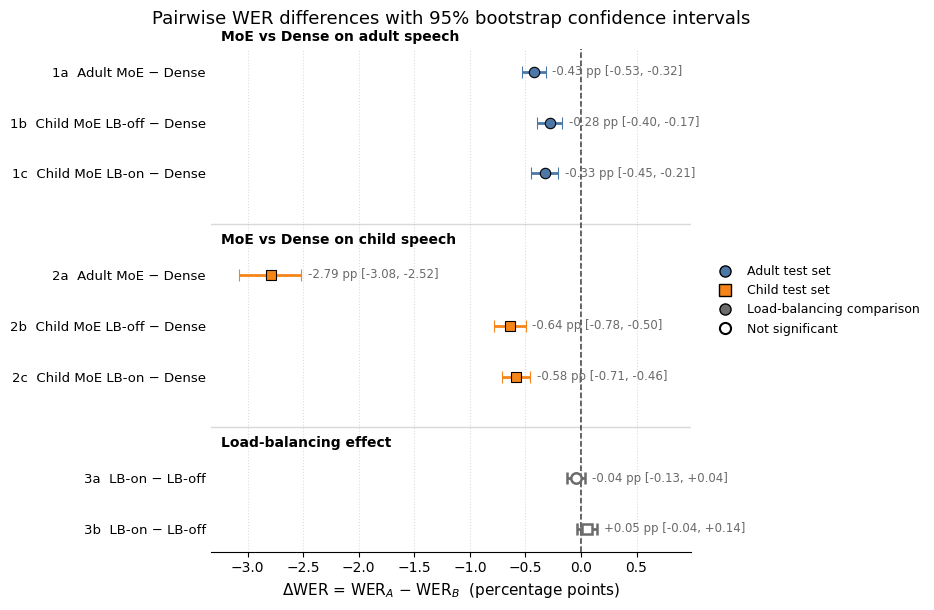

Saved:
/lp-dev/amelia/inclusive-asr-moe/stats/cache_en/fig_rq1_bootstrap_wer_diff_forest_clean.png
/lp-dev/amelia/inclusive-asr-moe/stats/cache_en/fig_rq1_bootstrap_wer_diff_forest_clean.pdf


In [17]:
# %% [markdown]
# ## 12. Thesis figure: clean forest plot of bootstrap WER differences

# %%
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Copy and prepare results ─────────────────────────────────────────────────
plot_df = res.copy().sort_values("Test").reset_index(drop=True)

# Human-readable labels
label_map = {
    "1a": "Adult MoE − Dense",
    "1b": "Child MoE LB-off − Dense",
    "1c": "Child MoE LB-on − Dense",
    "2a": "Adult MoE − Dense",
    "2b": "Child MoE LB-off − Dense",
    "2c": "Child MoE LB-on − Dense",
    "3a": "LB-on − LB-off",
    "3b": "LB-on − LB-off",
}

group_map = {
    "1": "MoE vs Dense on adult speech",
    "2": "MoE vs Dense on child speech",
    "3": "Load-balancing effect",
}

plot_df["label"] = plot_df["Test"].map(label_map)
plot_df["group"] = plot_df["Test"].str[0].map(group_map)

# Add blank spacer rows between groups
rows = []
current_group = None
y = 0

for _, row in plot_df.iterrows():
    if current_group is not None and row["group"] != current_group:
        rows.append({"is_spacer": True, "y": y})
        y += 1

    r = row.to_dict()
    r["is_spacer"] = False
    r["y"] = y
    rows.append(r)
    y += 1
    current_group = row["group"]

plot_df2 = pd.DataFrame(rows)

# Reverse y-axis order so first test appears at top
max_y = plot_df2["y"].max()
plot_df2["y_plot"] = max_y - plot_df2["y"]

data_df = plot_df2[~plot_df2["is_spacer"]].copy()

# ── Visual settings ──────────────────────────────────────────────────────────
colors = {
    "adult": "#4C78A8",
    "child": "#F58518",
}

# Use neutral color for load-balancing if desired
def row_color(row):
    if str(row["Test"]).startswith("3"):
        return "#6B6B6B"
    return colors.get(row["Test set"], "#6B6B6B")

def row_marker(row):
    if row["Test set"] == "adult":
        return "o"
    if row["Test set"] == "child":
        return "s"
    return "o"

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9.5, 6.2))

for _, row in data_df.iterrows():
    x = row["diff (pp)"]
    lo = row["CI low"]
    hi = row["CI high"]
    y = row["y_plot"]

    color = row_color(row)
    marker = row_marker(row)

    # Confidence interval
    ax.errorbar(
        x=x,
        y=y,
        xerr=[[x - lo], [hi - x]],
        fmt=marker,
        markersize=7.5,
        linewidth=2,
        capsize=4,
        capthick=1.8,
        color=color,
        markeredgecolor="black" if row["Significant"] else color,
        markerfacecolor=color if row["Significant"] else "white",
        markeredgewidth=0.8 if row["Significant"] else 1.8,
        zorder=3
    )

    # Numeric annotation
    txt = f"{x:+.2f} pp [{lo:+.2f}, {hi:+.2f}]"
    ax.text(
        hi + 0.06,
        y,
        txt,
        va="center",
        ha="left",
        fontsize=8.5,
        color="dimgray"
    )

# Zero reference line
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.1,
    alpha=0.8,
    zorder=1
)

# Light horizontal group separators
for _, row in plot_df2[plot_df2["is_spacer"]].iterrows():
    ax.axhline(
        row["y_plot"],
        color="0.85",
        linewidth=1,
        zorder=0
    )

# ── Y-axis labels ────────────────────────────────────────────────────────────
yticks = []
yticklabels = []

for _, row in data_df.iterrows():
    yticks.append(row["y_plot"])
    yticklabels.append(f"{row['Test']}  {row['label']}")

ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels, fontsize=9.5)

# Group headers
for group, sub in data_df.groupby("group", sort=False):
    y_top = sub["y_plot"].max()
    ax.text(
        ax.get_xlim()[0],
        y_top + 0.55,
        group,
        ha="left",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black"
    )

# ── Axis labels and title ────────────────────────────────────────────────────
ax.set_xlabel(
    r"$\Delta$WER = WER$_A$ − WER$_B$  (percentage points)",
    fontsize=11
)

ax.set_title(
    "Pairwise WER differences with 95% bootstrap confidence intervals",
    fontsize=13,
    pad=18
)


# ── Legend outside the plotting area ─────────────────────────────────────────
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=colors["adult"],
        markeredgecolor="black",
        markersize=8,
        label="Adult test set"
    ),
    Line2D(
        [0], [0],
        marker="s",
        color="none",
        markerfacecolor=colors["child"],
        markeredgecolor="black",
        markersize=8,
        label="Child test set"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="#6B6B6B",
        markeredgecolor="black",
        markersize=8,
        label="Load-balancing comparison"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.5,
        markersize=8,
        label="Not significant"
    ),
]

ax.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=9
)

# ── Styling ─────────────────────────────────────────────────────────────────
ax.grid(axis="x", linestyle=":", linewidth=0.8, alpha=0.45)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", length=0)

# Add extra room on the right for annotations
xmin = min(data_df["CI low"].min() - 0.25, -0.25)
xmax = max(data_df["CI high"].max() + 0.85, 0.35)
ax.set_xlim(xmin, xmax)

plt.tight_layout()

# Save
out_png = os.path.join(CACHE, "fig_rq1_bootstrap_wer_diff_forest_clean.png")
out_pdf = os.path.join(CACHE, "fig_rq1_bootstrap_wer_diff_forest_clean.pdf")

fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

plt.show()

print("Saved:")
print(out_png)
print(out_pdf)

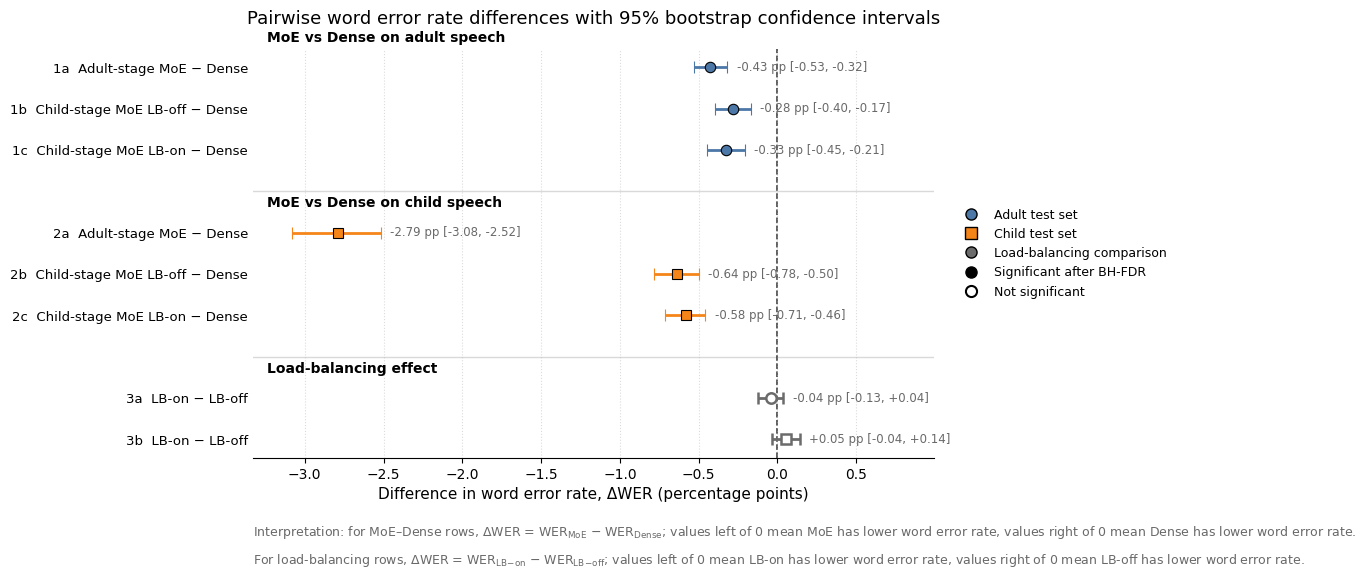

Saved:
/lp-dev/amelia/inclusive-asr-moe/stats/cache_en/fig_rq1_bootstrap_wer_diff_forest_interpretable.png
/lp-dev/amelia/inclusive-asr-moe/stats/cache_en/fig_rq1_bootstrap_wer_diff_forest_interpretable.pdf


In [20]:
# %% [markdown]
# ## 12. Thesis figure: clean forest plot of bootstrap WER differences

# %%
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Check required object ───────────────────────────────────────────────────
if "res" not in globals():
    raise RuntimeError(
        "res is not defined. Run the statistical test cells before running this figure."
    )

# ── Copy and prepare results ─────────────────────────────────────────────────
plot_df = res.copy().sort_values("Test").reset_index(drop=True)

# Human-readable labels
label_map = {
    "1a": "Adult-stage MoE − Dense",
    "1b": "Child-stage MoE LB-off − Dense",
    "1c": "Child-stage MoE LB-on − Dense",
    "2a": "Adult-stage MoE − Dense",
    "2b": "Child-stage MoE LB-off − Dense",
    "2c": "Child-stage MoE LB-on − Dense",
    "3a": "LB-on − LB-off",
    "3b": "LB-on − LB-off",
}

group_map = {
    "1": "MoE vs Dense on adult speech",
    "2": "MoE vs Dense on child speech",
    "3": "Load-balancing effect",
}

plot_df["label"] = plot_df["Test"].map(label_map)
plot_df["group"] = plot_df["Test"].str[0].map(group_map)

# Add interpretation labels per row
def comparison_formula(row):
    if str(row["Test"]).startswith("3"):
        return r"$\Delta$WER = WER$_{\mathrm{LB\mbox{-}on}}$ − WER$_{\mathrm{LB\mbox{-}off}}$"
    return r"$\Delta$WER = WER$_{\mathrm{MoE}}$ − WER$_{\mathrm{Dense}}$"

plot_df["formula"] = plot_df.apply(comparison_formula, axis=1)

# Add blank spacer rows between groups
rows = []
current_group = None
y = 0

for _, row in plot_df.iterrows():
    if current_group is not None and row["group"] != current_group:
        rows.append({"is_spacer": True, "y": y})
        y += 1

    r = row.to_dict()
    r["is_spacer"] = False
    r["y"] = y
    rows.append(r)
    y += 1
    current_group = row["group"]

plot_df2 = pd.DataFrame(rows)

# Reverse y-axis order so first test appears at top
max_y = plot_df2["y"].max()
plot_df2["y_plot"] = max_y - plot_df2["y"]

data_df = plot_df2[~plot_df2["is_spacer"]].copy()

# ── Visual settings ──────────────────────────────────────────────────────────
colors = {
    "adult": "#4C78A8",
    "child": "#F58518",
}

def row_color(row):
    if str(row["Test"]).startswith("3"):
        return "#6B6B6B"
    return colors.get(row["Test set"], "#6B6B6B")

def row_marker(row):
    if row["Test set"] == "adult":
        return "o"
    if row["Test set"] == "child":
        return "s"
    return "o"

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10.4, 6.6))

for _, row in data_df.iterrows():
    x = row["diff (pp)"]
    lo = row["CI low"]
    hi = row["CI high"]
    y = row["y_plot"]

    color = row_color(row)
    marker = row_marker(row)

    # Confidence interval + point estimate
    ax.errorbar(
        x=x,
        y=y,
        xerr=[[x - lo], [hi - x]],
        fmt=marker,
        markersize=7.5,
        linewidth=2,
        capsize=4,
        capthick=1.8,
        color=color,
        markeredgecolor="black" if row["Significant"] else color,
        markerfacecolor=color if row["Significant"] else "white",
        markeredgewidth=0.8 if row["Significant"] else 1.8,
        zorder=3
    )

    # Numeric annotation
    txt = f"{x:+.2f} pp [{lo:+.2f}, {hi:+.2f}]"
    ax.text(
        hi + 0.06,
        y,
        txt,
        va="center",
        ha="left",
        fontsize=8.5,
        color="dimgray"
    )

# Zero reference line
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.1,
    alpha=0.8,
    zorder=1
)

# Light horizontal group separators
for _, row in plot_df2[plot_df2["is_spacer"]].iterrows():
    ax.axhline(
        row["y_plot"],
        color="0.85",
        linewidth=1,
        zorder=0
    )

# ── Y-axis labels ────────────────────────────────────────────────────────────
yticks = []
yticklabels = []

for _, row in data_df.iterrows():
    yticks.append(row["y_plot"])
    yticklabels.append(f"{row['Test']}  {row['label']}")

ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels, fontsize=9.5)

# Group headers
for group, sub in data_df.groupby("group", sort=False):
    y_top = sub["y_plot"].max()
    ax.text(
        ax.get_xlim()[0],
        y_top + 0.55,
        group,
        ha="left",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black"
    )

# ── Axis labels and title ────────────────────────────────────────────────────
ax.set_xlabel(
    "Difference in word error rate, ΔWER (percentage points)",
    fontsize=11
)

ax.set_title(
    "Pairwise word error rate differences with 95% bootstrap confidence intervals",
    fontsize=13,
    pad=18
)
# ── Add bottom interpretation line ───────────────────────────────────────────
# This makes the sign of ΔWER explicit.
ax.text(
    0.00,
    -0.16,
    r"Interpretation: for MoE–Dense rows, $\Delta$WER = WER$_{\mathrm{MoE}}$ − WER$_{\mathrm{Dense}}$; "
    r"values left of 0 mean MoE has lower word error rate, values right of 0 mean Dense has lower word error rate.",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    color="dimgray"
)

ax.text(
    0.00,
    -0.23,
    r"For load-balancing rows, $\Delta$WER = WER$_{\mathrm{LB\!-\!on}}$ − WER$_{\mathrm{LB\!-\!off}}$; "
    r"values left of 0 mean LB-on has lower word error rate, values right of 0 mean LB-off has lower word error rate.",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9,
    color="dimgray"
)



# ── Legend outside the plotting area ─────────────────────────────────────────
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=colors["adult"],
        markeredgecolor="black",
        markersize=8,
        label="Adult test set"
    ),
    Line2D(
        [0], [0],
        marker="s",
        color="none",
        markerfacecolor=colors["child"],
        markeredgecolor="black",
        markersize=8,
        label="Child test set"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="#6B6B6B",
        markeredgecolor="black",
        markersize=8,
        label="Load-balancing comparison"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=8,
        label="Significant after BH-FDR"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.5,
        markersize=8,
        label="Not significant"
    ),
]

ax.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=9
)

# ── Styling ─────────────────────────────────────────────────────────────────
ax.grid(axis="x", linestyle=":", linewidth=0.8, alpha=0.45)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="y", length=0)

# Add extra room on the right for annotations
xmin = min(data_df["CI low"].min() - 0.25, -0.25)
xmax = max(data_df["CI high"].max() + 0.85, 0.35)
ax.set_xlim(xmin, xmax)

# More bottom margin for interpretation text
plt.subplots_adjust(bottom=0.26, right=0.78)

# Save
out_png = os.path.join(CACHE, "fig_rq1_bootstrap_wer_diff_forest_interpretable.png")
out_pdf = os.path.join(CACHE, "fig_rq1_bootstrap_wer_diff_forest_interpretable.pdf")

fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

plt.show()

print("Saved:")
print(out_png)
print(out_pdf)